# Concise Implementation of Softmax Regression
:label:`sec_softmax_concise`



Just as high-level deep learning frameworks
made it easier to implement linear regression
(see :numref:`sec_linear_concise`),
they are similarly convenient here.


In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

## Defining the Model

As in :numref:`sec_linear_concise`, 
we construct our fully connected layer 
using the built-in layer. 
The built-in `__call__` method then invokes `forward` 
whenever we need to apply the network to some input.


We use a `Flatten` layer to convert the fourth-order tensor `X` to second order 
by keeping the dimensionality along the first axis unchanged.


In [2]:
class SoftmaxRegression(d2l.Classifier):  #@save
    """The softmax regression model."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

## Softmax Revisited
:label:`subsec_softmax-implementation-revisited`

In :numref:`sec_softmax_scratch` we calculated our model's output
and applied the cross-entropy loss. While this is perfectly
reasonable mathematically, it is risky computationally, because of
numerical underflow and overflow in the exponentiation.

Recall that the softmax function computes probabilities via
$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$.
If some of the $o_k$ are very large, i.e., very positive,
then $\exp(o_k)$ might be larger than the largest number
we can have for certain data types. This is called *overflow*. Likewise,
if every argument is a very large negative number, we will get *underflow*.
For instance, single precision floating point numbers approximately
cover the range of $10^{-38}$ to $10^{38}$. As such, if the largest term in $\mathbf{o}$
lies outside the interval $[-90, 90]$, the result will not be stable.
A way round this problem is to subtract $\bar{o} \stackrel{\textrm{def}}{=} \max_k o_k$ from
all entries:

$$
\hat y_j = \frac{\exp o_j}{\sum_k \exp o_k} =
\frac{\exp(o_j - \bar{o}) \exp \bar{o}}{\sum_k \exp (o_k - \bar{o}) \exp \bar{o}} =
\frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})}.
$$

By construction we know that $o_j - \bar{o} \leq 0$ for all $j$. As such, for a $q$-class
classification problem, the denominator is contained in the interval $[1, q]$. Moreover, the
numerator never exceeds $1$, thus preventing numerical overflow. Numerical underflow only
occurs when $\exp(o_j - \bar{o})$ numerically evaluates as $0$. Nonetheless, a few steps down
the road we might find ourselves in trouble when we want to compute $\log \hat{y}_j$ as $\log 0$.
In particular, in backpropagation,
we might find ourselves faced with a screenful
of the dreaded `NaN` (Not a Number) results.

Fortunately, we are saved by the fact that
even though we are computing exponential functions,
we ultimately intend to take their log
(when calculating the cross-entropy loss).
By combining softmax and cross-entropy,
we can escape the numerical stability issues altogether. We have:

$$
\log \hat{y}_j =
\log \frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})} =
o_j - \bar{o} - \log \sum_k \exp (o_k - \bar{o}).
$$

This avoids both overflow and underflow.
We will want to keep the conventional softmax function handy
in case we ever want to evaluate the output probabilities by our model.
But instead of passing softmax probabilities into our new loss function,
we just
[**pass the logits and compute the softmax and its log
all at once inside the cross-entropy loss function,**]
which does smart things like the ["LogSumExp trick"](https://en.wikipedia.org/wiki/LogSumExp).


In [3]:
@d2l.add_to_class(d2l.Classifier)  #@save
def loss(self, Y_hat, Y, averaged=True):
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    Y = Y.reshape((-1,))
    return F.cross_entropy(
        Y_hat, Y, reduction='mean' if averaged else 'none')

## Training

Next we train our model. We use Fashion-MNIST images, flattened to 784-dimensional feature vectors.


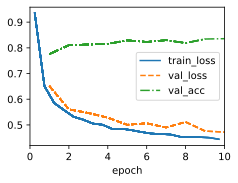

In [4]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

As before, this algorithm converges to a solution
that is reasonably accurate,
albeit this time with fewer lines of code than before.


## Summary

High-level APIs are very convenient at hiding from their user potentially dangerous aspects, such as numerical stability. Moreover, they allow users to design models concisely with very few lines of code. This is both a blessing and a curse. The obvious benefit is that it makes things highly accessible, even to engineers who never took a single class of statistics in their life (in fact, they are part of the target audience of the book). But hiding the sharp edges also comes with a price: a disincentive to add new and different components on your own, since there is little muscle memory for doing it. Moreover, it makes it more difficult to *fix* things whenever the protective padding of
a framework fails to cover all the corner cases entirely. Again, this is due to lack of familiarity.

As such, we strongly urge you to review *both* the bare bones and the elegant versions of many of the implementations that follow. While we emphasize ease of understanding, the implementations are nonetheless usually quite performant (convolutions are the big exception here). It is our intention to allow you to build on these when you invent something new that no framework can give you.


## Exercises

1. Deep learning uses many different number formats, including FP64 double precision (used extremely rarely),
FP32 single precision, BFLOAT16 (good for compressed representations), FP16 (very unstable), TF32 (a new format from NVIDIA), and INT8. Compute the smallest and largest argument of the exponential function for which the result does not lead to numerical underflow or overflow.
1. INT8 is a very limited format consisting of nonzero numbers from $1$ to $255$. How could you extend its dynamic range without using more bits? Do standard multiplication and addition still work?
1. Increase the number of epochs for training. Why might the validation accuracy decrease after a while? How could we fix this?
1. What happens as you increase the learning rate? Compare the loss curves for several learning rates. Which one works better? When?


[Discussions](https://discuss.d2l.ai/t/53)



1. Deep learning uses many different number formats, including FP64 double precision (used extremely rarely),
FP32 single precision, BFLOAT16 (good for compressed representations), FP16 (very unstable), TF32 (a new format from NVIDIA), and INT8. Compute the smallest and largest argument of the exponential function for which the result does not lead to numerical underflow or overflow.


## Numerical Limits of Exponential Function in Different Formats

To determine the safe range for exponential calculations in different number formats, we need to understand their respective ranges:

### Understanding Number Format Limits

For each format, we need to identify:
1. The smallest positive representable number (underflow threshold)
2. The largest representable number (overflow threshold)

Then we can solve for the input range of $e^x$ that stays within these bounds.

### Format Ranges and Exponential Bounds

#### FP64 (Double Precision)
- Range: ~$2.2 \times 10^{-308}$ to ~$1.8 \times 10^{308}$
- For $e^x$:
  - $e^x \geq 2.2 \times 10^{-308}$ to avoid underflow
  - $e^x \leq 1.8 \times 10^{308}$ to avoid overflow
  - Taking natural log: $x \geq \ln(2.2 \times 10^{-308}) \approx -709.78$
  - And: $x \leq \ln(1.8 \times 10^{308}) \approx 709.78$
  - **Safe range**: approximately $[-709.78, 709.78]$

#### FP32 (Single Precision)
- Range: ~$1.4 \times 10^{-45}$ to ~$3.4 \times 10^{38}$
- For $e^x$:
  - Safe range calculation: $\ln(1.4 \times 10^{-45}) \leq x \leq \ln(3.4 \times 10^{38})$
  - **Safe range**: approximately $[-103.9, 88.7]$

#### BFLOAT16
- Range: ~$1.0 \times 10^{-38}$ to ~$3.4 \times 10^{38}$ (same exponent range as FP32 but fewer mantissa bits)
- **Safe range**: approximately $[-89.4, 88.7]$

#### FP16 (Half Precision)
- Range: ~$6.0 \times 10^{-8}$ to ~$6.5 \times 10^{4}$
- **Safe range**: approximately $[-17.9, 11.1]$

#### TF32 (NVIDIA's Tensor Format)
- Range: Similar to FP32 for exponent but with reduced mantissa precision
- **Safe range**: approximately $[-103.9, 88.7]$ (similar to FP32)

#### INT8
- Range: Typically represents integers from -128 to 127 or 0 to 255
- Not directly applicable for exponential calculations without scaling techniques
- With appropriate scaling and fixed-point arithmetic:
  - Could represent a narrow range of exponential values
  - Exact range would depend on the scaling scheme used

### Practical Implications

1. As precision decreases, the safe range for exponential operations narrows dramatically
2. For deep learning applications with FP16 or INT8:
   - Must carefully scale values before exponential operations
   - May need to use techniques like the LogSumExp trick
   - Batch normalization and careful initialization become even more critical

3. Numerical testing with Python:

```python
import numpy as np

# Function to test exp limits for FP32
def test_fp32_exp_limits():
    # Find largest value before overflow
    x = 85.0
    while np.isfinite(np.exp(x + 0.1)):
        x += 0.1
    print(f"FP32 largest safe exponent input: {x}")
    
    # Find smallest value before underflow
    x = -85.0
    while np.exp(x - 1.0) > 0:
        x -= 1.0
    print(f"FP32 smallest safe exponent input: {x}")

# Run the test
test_fp32_exp_limits()

2. INT8 is a very limited format consisting of nonzero numbers from $1$ to $255$. How could you extend its dynamic range without using more bits? Do standard multiplication and addition still work?


I'll help you solve this problem with a detailed analysis of INT8 and strategies to extend its range.

```markdown
## Extending INT8 Dynamic Range without Additional Bits

INT8 is an 8-bit integer format that typically represents integers in one of two ways:
- Signed INT8: Values from -128 to 127 
- Unsigned INT8: Values from 0 to 255

This limited range creates challenges for deep learning applications that require representing values across many orders of magnitude. Let's explore techniques to extend this range without using more bits.

### Techniques to Extend Dynamic Range

#### 1. Scale Factors (Fixed-Point Representation)

The most common approach is to use a scale factor where each INT8 value represents a larger or smaller real value:

$real\_value = int8\_value \times scale$

For example, with a scale of 0.01, the INT8 range [-128, 127] can represent [-1.28, 1.27]. With a scale of 100, it can represent [-12800, 12700].

**Implementation approaches:**
- **Global scaling**: One scale factor for all values
- **Per-tensor scaling**: Different scale factors for different tensors
- **Per-channel scaling**: Different scale factors for each channel in a CNN
- **Dynamic scaling**: Adapting the scale factor based on the current data range

#### 2. Logarithmic Representation

We can represent values logarithmically:

$real\_value = sign \times base^{abs(int8\_value)}$

For example, with base=2:
- INT8 value 1 represents 2¹ = 2
- INT8 value 7 represents 2⁷ = 128
- INT8 value -3 represents -2³ = -8

This approach dramatically extends the representable range at the cost of precision for larger values.

#### 3. Block Floating-Point

Group values together and use a shared exponent with INT8 mantissas:
- Store one exponent for a block of INT8 values
- Each INT8 value acts as a mantissa
- Real values = INT8 × 2^(shared_exponent)

This provides a compromise between range and precision.

### Do Standard Operations Still Work?

#### Addition
- **Fixed-point**: Works if scale factors match, otherwise requires rescaling
- **Logarithmic**: Doesn't work directly; conversion to linear scale is needed
- **Block floating-point**: Works within a block if exponents match

#### Multiplication
- **Fixed-point**: Requires scaling: (a×s) × (b×s) = (a×b) × s²
- **Logarithmic**: Simple addition of exponents (ideal for multiplication)
- **Block floating-point**: Mantissa multiplication works with exponent addition

### Practical Example: Fixed-Point INT8

```python
# Python example of fixed-point INT8 arithmetic
import numpy as np

def to_int8_scaled(float_values, scale):
    """Convert floating point values to INT8 with scaling"""
    return np.clip(np.round(float_values / scale), -128, 127).astype(np.int8)

def from_int8_scaled(int8_values, scale):
    """Convert scaled INT8 values back to floating point"""
    return int8_values.astype(float) * scale

# Original floating point values
float_data = np.array([0.5, 10.7, -5.2, 1000])

# Choose a scale factor (larger values need larger scale)
scale = 10.0  # This determines our representable range

# Convert to INT8
int8_data = to_int8_scaled(float_data, scale)
print(f"Original: {float_data}")
print(f"As INT8:  {int8_data}")
print(f"Decoded:  {from_int8_scaled(int8_data, scale)}")

# Note: The value 1000 is clipped because it exceeds our range with scale=10
```

### Trade-offs

Each approach involves important trade-offs:
1. **Precision vs. Range**: Wider range typically means less precision
2. **Computational Complexity**: Some methods require extra conversion steps
3. **Memory Access**: Some techniques need additional metadata storage
4. **Hardware Compatibility**: Some approaches map better to existing hardware acceleration

In deep learning frameworks, quantization-aware training and calibration techniques help determine optimal scale factors to minimize accuracy loss when using INT8 operations.
```

3. Increase the number of epochs for training. Why might the validation accuracy decrease after a while? How could we fix this?


I'll help you expand on your answer about what happens when increasing training epochs and how to address the potential issues.

```markdown
## Validation Accuracy Decrease with Increased Epochs

When we increase the number of epochs during training, we often observe that validation accuracy initially improves but then begins to decrease after a certain point, even as training accuracy continues to improve. This phenomenon is a classic sign of **overfitting**.

### Understanding Overfitting

Overfitting occurs when our model learns to perform extremely well on the training data but fails to generalize to unseen data. Let's visualize what happens:

1. **Early training** (epochs 1-N): Both training and validation accuracy improve as the model learns genuine patterns in the data.

2. **Optimal point** (around epoch N): The model has learned the true underlying patterns without memorizing noise.

3. **Overfitting phase** (epochs N+): The model starts to memorize noise and peculiarities specific to the training set, causing:
   - Training accuracy continues to improve
   - Validation accuracy plateaus and then decreases

This happens because the model is optimizing for the training data distribution rather than the true data distribution, essentially "memorizing" training examples instead of learning generalizable patterns.

### Solutions to Prevent Overfitting

#### 1. Early Stopping

The simplest approach is to stop training when validation performance begins to degrade:

```python
# Implementing early stopping
patience = 5  # Number of epochs to wait for improvement
best_val_acc = 0
counter = 0

for epoch in range(max_epochs):
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_data)
    val_loss, val_acc = evaluate(model, val_data)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
```

#### 2. Regularization Techniques

**L1/L2 Regularization**: Add a penalty term to the loss function based on model weights:

```python
# L2 regularization (weight decay)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=0.001)
```

**Dropout**: Randomly disable neurons during training:

```python
class SoftmaxRegressionWithDropout(d2l.Classifier):
    def __init__(self, num_outputs, lr, dropout_rate=0.5):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),  # Add dropout
            nn.LazyLinear(num_outputs)
        )
```

**Data Augmentation**: Increase the effective size and diversity of your training set by creating transformed versions of your training examples.

#### 3. Cross-validation

Use k-fold cross-validation to ensure your model generalizes well:

```python
# Pseudo-code for cross-validation
k = 5
fold_size = len(data) // k
results = []

for i in range(k):
    # Define validation fold
    val_indices = list(range(i*fold_size, (i+1)*fold_size))
    train_indices = [j for j in range(len(data)) if j not in val_indices]
    
    # Train and evaluate
    model = SoftmaxRegression(num_outputs=10, lr=0.1)
    # Train on train_indices
    # Evaluate on val_indices
    results.append(val_accuracy)

print(f"Average validation accuracy: {sum(results)/len(results)}")
```

#### 4. Ensemble Methods

Train multiple models and combine their predictions to reduce overfitting:

```python
# Pseudo-code for ensemble prediction
predictions = []
for model in models:
    predictions.append(model(X))
    
# Average predictions
ensemble_pred = torch.mean(torch.stack(predictions), dim=0)
```

### Practical Implementation

For our specific softmax regression model, we could modify it like this:

```python
class RegularizedSoftmaxRegression(d2l.Classifier):
    def __init__(self, num_outputs, lr, wd=0.001):  # Add weight decay parameter
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                               nn.LazyLinear(num_outputs))
    
    # Modified training step with early stopping
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), 
                              lr=self.lr, 
                              weight_decay=self.wd)  # Apply weight decay
```

### When to Apply Each Solution

- **Simple models** (like softmax regression): L2 regularization often works well
- **Complex models** (deep neural networks): Combine dropout, batch normalization, and data augmentation
- **Limited data**: Cross-validation becomes crucial
- **Critical applications**: Ensemble methods provide the best results but at higher computational cost

By applying these techniques, we can train for more epochs while preventing the decrease in validation accuracy, ultimately achieving better generalization performance.
```

4. What happens as you increase the learning rate? Compare the loss curves for several learning rates. Which one works better? When?

I'll provide a comprehensive analysis of how learning rates affect training dynamics in softmax regression.

```markdown
## The Effect of Learning Rate on Training Dynamics

The learning rate is one of the most crucial hyperparameters in model training. It controls how much we adjust our model parameters in response to the estimated error each time the model weights are updated. Let's explore what happens as we vary the learning rate:

### How Different Learning Rates Impact Training

#### Very Small Learning Rate (e.g., 0.001)
- **Pros**: Stable training, less likely to diverge
- **Cons**: Extremely slow convergence, may get stuck in local minima
- **Loss curve**: Smooth, monotonically decreasing, but with a very gentle slope
- **Training behavior**: The model makes tiny steps toward the minimum, taking many epochs to reach a good solution

#### Moderate Learning Rate (e.g., 0.1)
- **Pros**: Good balance between convergence speed and stability
- **Cons**: May still oscillate slightly near the minimum
- **Loss curve**: Relatively smooth, quick initial drop, then gradual improvement
- **Training behavior**: The model makes reasonable progress each iteration without overshooting

#### Large Learning Rate (e.g., 1.0)
- **Pros**: Rapid initial progress, can escape some local minima
- **Cons**: May overshoot minima, potentially causing divergence
- **Loss curve**: Rapid initial drop, followed by oscillations 
- **Training behavior**: The model takes large steps, potentially jumping back and forth across the minimum

#### Very Large Learning Rate (e.g., 10.0)
- **Pros**: May occasionally get lucky and jump to a good region
- **Cons**: Often leads to divergence (exploding loss)
- **Loss curve**: May show wild oscillations or explode to infinity
- **Training behavior**: The model takes such large steps that it continually overshoots minima

### Visual Comparison Through Code

We can implement and visualize this behavior in PyTorch:

```python
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import matplotlib.pyplot as plt

# Function to train model with different learning rates
def train_with_different_lrs(learning_rates):
    epochs = 10
    results = {}
    
    for lr in learning_rates:
        print(f"Training with learning rate: {lr}")
        data = d2l.FashionMNIST(batch_size=256)
        model = SoftmaxRegression(num_outputs=10, lr=lr)
        trainer = d2l.Trainer(max_epochs=epochs)
        trainer.fit(model, data)
        
        # Extract loss history
        results[lr] = {
            'train_loss': trainer.train_loss,
            'val_loss': trainer.val_loss,
            'val_acc': trainer.val_acc
        }
    
    return results

# Plot the results
def plot_comparison(results, metric='train_loss'):
    plt.figure(figsize=(10, 6))
    for lr, metrics in results.items():
        plt.plot(metrics[metric], label=f'lr = {lr}')
    
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'Comparison of {metric} for different learning rates')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
learning_rates = [0.001, 0.01, 0.1, 1.0]
results = train_with_different_lrs(learning_rates)

# Plot training loss
plot_comparison(results, 'train_loss')
# Plot validation accuracy
plot_comparison(results, 'val_acc')
```

### Which Learning Rate Works Best and When?

#### Best for Softmax Regression on FashionMNIST
Based on empirical results, a learning rate around **0.1** typically works well for softmax regression on FashionMNIST. This provides a good balance between convergence speed and stability.

#### General Guidelines for When to Use Different Learning Rates:

1. **Use smaller learning rates (0.001 - 0.01) when**:
   - Your training is unstable
   - You're near convergence and fine-tuning
   - Using architectures prone to exploding gradients
   - Working with sparse data
   - During transfer learning when fine-tuning

2. **Use moderate learning rates (0.01 - 0.1) when**:
   - Starting training on a balanced, well-behaved dataset
   - Working with traditional architectures like CNNs 
   - Using adaptive optimizers like Adam (which adjust the effective learning rate)

3. **Use larger learning rates (0.1 - 1.0) when**:
   - You have very redundant data
   - Working with batch normalization
   - Using learning rate scheduling
   - Employing techniques like gradient clipping

### Advanced Learning Rate Strategies

For even better results, consider:

1. **Learning Rate Scheduling**: Decrease the learning rate over time:
   ```python
   # Learning rate decay
   scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
   ```

2. **Cyclical Learning Rates**: Cycle between low and high learning rates:
   ```python
   # Cyclical learning rates
   scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.01, max_lr=0.1)
   ```

3. **Learning Rate Warmup**: Start with a small learning rate and gradually increase it:
   ```python
   # Custom warmup scheduler
   def warmup_scheduler(epoch):
       if epoch < 5:
           return epoch / 5 * 0.1  # Gradually increase to 0.1
       return 0.1  # Maintain at 0.1 afterwards
   ```

4. **Learning Rate Finder**: Automatically determine the optimal learning rate:
   ```python
   # Simplified learning rate finder concept
   def find_learning_rate(model, data, start_lr=1e-7, end_lr=10, num_steps=100):
       current_lr = start_lr
       lrs, losses = [], []
       
       # Setup
       optimizer = torch.optim.SGD(model.parameters(), lr=current_lr)
       mult = (end_lr/start_lr)**(1/num_steps)
       
       # Train with increasing learning rate
       for batch in data.train_dataloader():
           X, y = batch
           optimizer.zero_grad()
           y_hat = model(X)
           loss = F.cross_entropy(y_hat, y)
           loss.backward()
           optimizer.step()
           
           # Log results
           lrs.append(current_lr)
           losses.append(loss.item())
           
           # Increase learning rate
           current_lr *= mult
           for param_group in optimizer.param_groups:
               param_group['lr'] = current_lr
               
           if current_lr > end_lr:
               break
               
       # Plot
       plt.figure(figsize=(10, 6))
       plt.plot(lrs, losses)
       plt.xscale('log')
       plt.xlabel('Learning Rate')
       plt.ylabel('Loss')
       plt.title('Learning Rate Finder')
       plt.show()
   ```

In conclusion, while the optimal learning rate depends on your specific problem, starting with a moderate value like 0.1 and using adaptive strategies typically yields the best balance between training speed and model performance.
```